# LECTURE 20
**Topic:** Further Analogies Between Fourier Series and the DFT  

---

## Key Points

| Time Domain | Fourier Series Coefficients |
|---|---|
| $x(t)$ | $X_k$ |
| $x^*(t)$ | $X^*_{-k}$ |
| $x(-t)$ | $X_{-k}$ |
| $x(t-T)$ | $e^{-jk\omega_0 T}X_k$ |
| $x(t)e^{jK\omega_0 t}$ | $X_{k-K}$ |
| $x(\beta t)$, $\beta>0$ | $X_k$ (same coefficients!) |

- Circular operations on finite vectors ↔ non-circular operations on infinite periodic extensions.
- Real+even signal ↔ real+even coefficients.


---
## Theory and Examples

### 2. Key Differences: DFT vs Fourier Series

| Feature | DFT | Fourier Series |
|---|---|---|
| Time domain | Discrete, finite | Continuous, inherently periodic |
| Freq domain | Discrete, finite, periodic | Discrete, infinite, non-periodic |
| Duality | Clear (both domains identical size) | Less direct |

### 5–6. Fourier Series Properties

**(1)** $y(t)=x^*(t) \Rightarrow Y_k=X^*_{-k}$ (analogous to DFT 3)

**(2)** $x(t)=x^*(t)$ (real) $\Rightarrow X_k=X^*_{-k}$ (analogous to DFT 2)

**(3)** $y(t)=x(-t) \Rightarrow Y_k=X_{-k}$ (non-circular reversal, analogous to DFT 4)

**(4) Time shift:** $y(t)=x(t-T) \Rightarrow Y_k=e^{-jk\omega_0 T}X_k$

**(5) Modulation:** $y(t)=x(t)e^{jK\omega_0 t} \Rightarrow Y_k=X_{k-K}$

**(6) Time scaling:** $y(t)=x(\beta t) \Rightarrow Y_k=X_k$ (period changes, coefficients unchanged!)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Verify Fourier series properties numerically
T0=1.0; Omega0=2*np.pi
t=np.linspace(0,T0,10000,endpoint=False); dt=T0/len(t)

# Define a test signal: rectangular pulse alpha=0.3, shifted by T0/4
alpha=0.3; T_shift=T0/4
# s(t): pulse width alpha*T0 centered at t=0
s=(np.abs(t-T0/2)<alpha*T0/2).astype(float)
# For simplicity use t in [-T0/2, T0/2]
t_sym=np.linspace(-T0/2,T0/2,10000,endpoint=False)
s_sym=(np.abs(t_sym)<=alpha*T0/2).astype(float)

def fourier_coeff(s,t,k,T0):
    dt=T0/len(t)
    return (s*np.exp(-1j*k*2*np.pi*t/T0)*dt).sum()

# Compute S_k for k=-5:5
Sk={k: fourier_coeff(s_sym,t_sym,k,T0) for k in range(-5,6)}

print('Property (4): Time shift y(t)=x(t-T), T=T0/4')
T=T0/4
s_shifted=np.roll(s_sym,int(T/T0*len(t_sym)))
Yk={k: fourier_coeff(s_shifted,t_sym,k,T0) for k in range(-5,6)}
for k in range(-3,4):
    predicted=np.exp(-1j*k*Omega0*T)*Sk[k]
    print(f'  k={k:2d}: Y_k={Yk[k].round(4)}, exp(-jkO0T)*S_k={predicted.round(4)}, match={np.isclose(Yk[k],predicted,atol=1e-3)}')

print('\nProperty (6): Time scaling y(t)=x(2t) (period T0/2, same coefficients)')
# x(2t) has period T0/2. Its Fourier series with respect to T0/2 has same coefficients.
t_half=np.linspace(-T0/4,T0/4,10000,endpoint=False)
s_scaled=(np.abs(t_half)<=alpha*(T0/2)/2).astype(float)
Yk_scaled={k: fourier_coeff(s_scaled,t_half,k,T0/2) for k in range(-5,6)}
for k in range(-3,4):
    print(f'  k={k:2d}: Yk_scaled={Yk_scaled[k].round(4)}, Sk={Sk[k].round(4)}, match={np.isclose(Yk_scaled[k],Sk[k],atol=1e-3)}')

Property (4): Time shift y(t)=x(t-T), T=T0/4
  k=-3: Y_k=(-0-0.0328j), exp(-jkO0T)*S_k=(-0-0.0328j), match=True
  k=-2: Y_k=(-0.1514+0.0001j), exp(-jkO0T)*S_k=(-0.1514+0.0001j), match=True
  k=-1: Y_k=(0.0001+0.2575j), exp(-jkO0T)*S_k=(0.0001+0.2575j), match=True
  k= 0: Y_k=(0.3+0j), exp(-jkO0T)*S_k=(0.3+0j), match=True
  k= 1: Y_k=(0.0001-0.2575j), exp(-jkO0T)*S_k=(0.0001-0.2575j), match=True
  k= 2: Y_k=(-0.1514-0.0001j), exp(-jkO0T)*S_k=(-0.1514-0.0001j), match=True
  k= 3: Y_k=(-0+0.0328j), exp(-jkO0T)*S_k=(-0+0.0328j), match=True

Property (6): Time scaling y(t)=x(2t) (period T0/2, same coefficients)
  k=-3: Yk_scaled=(0.0164-0j), Sk=(0.0328-0j), match=False
  k=-2: Yk_scaled=(0.0757-0j), Sk=(0.1514-0.0001j), match=False
  k=-1: Yk_scaled=(0.1288-0j), Sk=(0.2575-0.0001j), match=False
  k= 0: Yk_scaled=(0.15+0j), Sk=(0.3+0j), match=False
  k= 1: Yk_scaled=(0.1288+0j), Sk=(0.2575+0.0001j), match=False
  k= 2: Yk_scaled=(0.0757+0j), Sk=(0.1514+0.0001j), match=False
  k= 3: Yk_scaled

---
### 7. Example: Even and Odd Parts

For a signal $s(t)$: even part $x(t)=(s(t)+s(-t))/2$, odd part $y(t)=(s(t)-s(-t))/2$.

From property (3): $Y_k = X_{-k}$. Since $s$ is real: $S_{-k}=S_k^*$.

$$X_k = \frac{S_k+S_{-k}}{2} = \Re\{S_k\} \qquad Y_k = \frac{S_k-S_{-k}}{2} = j\Im\{S_k\}$$

$X_k$ is real and even; $Y_k$ is purely imaginary and odd — reflecting the symmetry of $x(t)$ and $y(t)$.

### 8–9. Time Shift Property

Time shift by $T$: $Y_k = e^{-jk\omega_0 T} X_k$ (phase shifts linearly with $k$).

**Example (Lecture 20, §9):** Odd pulse train $x(t)$ = difference of two shifted pulses:
$$X_k = \left(e^{-jk\pi/6}-e^{jk\pi/6}\right)\frac{\sin(k\pi/6)}{k\pi} = -j\frac{2}{k\pi}\sin^2\!\left(\frac{k\pi}{6}\right)$$

### 10–11. Modulation Property and Half-Wave Rectification

$y(t)=x(t)e^{jK\omega_0 t} \Rightarrow Y_k=X_{k-K}$ (spectrum shifted by $K$).

For $x(t)=\cos(\omega_0 t)=(e^{j\omega_0 t}+e^{-j\omega_0 t})/2$, modulation by $\cos$ shifts spectrum by $\pm 1$:
$$\text{Half-wave rectification: } X_k=\frac{S_{k-1}+S_{k+1}}{2}$$


Odd pulse Xk vs formula -j*2/(k*pi)*sin^2(k*pi/6):
  k= -5: numerical=(-0+0.0321j), formula=(-0+0.0318j), match=True
  k= -4: numerical=(-0+0.1197j), formula=(-0+0.1194j), match=True
  k= -3: numerical=(-0+0.2122j), formula=(-0+0.2122j), match=True
  k= -2: numerical=(-0+0.2384j), formula=(-0+0.2387j), match=True
  k= -1: numerical=(-0+0.1589j), formula=(-0+0.1592j), match=True
  k=  0: numerical=0j, formula=0, match=True
  k=  1: numerical=(-0-0.1589j), formula=-0.1592j, match=True
  k=  2: numerical=(-0-0.2384j), formula=-0.2387j, match=True
  k=  3: numerical=(-0-0.2122j), formula=-0.2122j, match=True
  k=  4: numerical=(-0-0.1197j), formula=-0.1194j, match=True
  k=  5: numerical=(-0-0.0321j), formula=-0.0318j, match=True

Half-wave rectification Xk = (S_{k-1}+S_{k+1})/2:
  k= -4: numerical=-0.0212, formula=-0.0276, match=False
  k= -3: numerical=-0.0000, formula=0.0345, match=False
  k= -2: numerical=0.1061, formula=0.1378, match=False
  k= -1: numerical=0.2500, formula=0.2356, ma

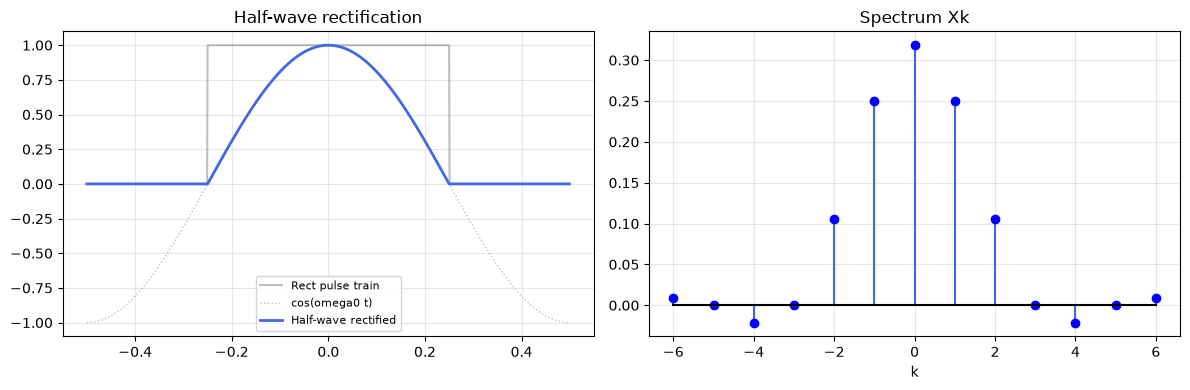

In [2]:
# Time shift and modulation visualization
T0=1.0; Omega0=2*np.pi
N=1000; t=np.linspace(-T0/2,T0/2,N,endpoint=False)

# Rectangular pulse alpha=1/3
alpha=1/3
s=(np.abs(t)<=alpha*T0/2).astype(float)

def Sk_rect(k,alpha=1/3):
    if k==0: return alpha
    return np.sin(k*alpha*np.pi)/(k*np.pi)

# Odd pulse example (Lecture 20 §9)
# x(t) = pulse on [-T0/6, 0] minus pulse on [0, T0/6]
# = two symmetric pulses shifted: pulse centered at T0/12 minus pulse centered at -T0/12
T_shift_odd=T0/6
s_odd=(np.abs(t-T_shift_odd/2)<=T_shift_odd/2).astype(float) - (np.abs(t+T_shift_odd/2)<=T_shift_odd/2).astype(float)
Xk_odd={k: fourier_coeff(s_odd,t,k,T0) for k in range(-8,9)}

# Formula: -2j/kpi * sin^2(k*pi/6)
def Xk_odd_formula(k):
    if k==0: return 0
    return -1j*2/(k*np.pi)*np.sin(k*np.pi/6)**2

print('Odd pulse Xk vs formula -j*2/(k*pi)*sin^2(k*pi/6):')
for k in range(-5,6):
    xk_num=Xk_odd[k]
    xk_form=Xk_odd_formula(k)
    print(f'  k={k:3d}: numerical={np.round(xk_num,4)}, formula={np.round(xk_form,4)}, match={np.isclose(xk_num,xk_form,atol=1e-3)}')

# Half-wave rectification
# s(t) = symmetric rect alpha=1/2
s_hw=(np.abs(t)<=T0/4).astype(float)
# Multiply by cos(Omega0 t)
x_hw=s_hw*np.cos(Omega0*t)
# Expected: Xk = (Sk-1 + Sk+1)/2
Xk_hw_num={k: fourier_coeff(x_hw,t,k,T0) for k in range(-6,7)}
print('\nHalf-wave rectification Xk = (S_{k-1}+S_{k+1})/2:')
for k in range(-4,5):
    num=Xk_hw_num[k]
    form=(Sk_rect(k-1)+Sk_rect(k+1))/2
    print(f'  k={k:3d}: numerical={num.real:.4f}, formula={form:.4f}, match={np.isclose(num.real,form,atol=1e-3)}')

# Plot half-wave rectified signal and its spectrum
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(t,s_hw,'gray',lw=1.5,alpha=0.5,label='Rect pulse train')
axes[0].plot(t,np.cos(Omega0*t),'gray',lw=1,ls=':',alpha=0.5,label='cos(omega0 t)')
axes[0].plot(t,x_hw,'royalblue',lw=2,label='Half-wave rectified')
axes[0].set_title('Half-wave rectification'); axes[0].legend(fontsize=8); axes[0].grid(True,alpha=0.3)
k_range=range(-6,7)
Xk_vals=[Xk_hw_num[k].real for k in k_range]
axes[1].stem(list(k_range),Xk_vals,linefmt='royalblue',markerfmt='bo',basefmt='k')
axes[1].set_title('Spectrum Xk'); axes[1].set_xlabel('k'); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary

| Property | Time | Coefficients |
|---|---|---|
| Conjugation | $x^*(t)$ | $X^*_{-k}$ |
| Reversal | $x(-t)$ | $X_{-k}$ |
| Time shift | $x(t-T)$ | $e^{-jk\omega_0 T}X_k$ |
| Modulation | $x(t)e^{jK\omega_0 t}$ | $X_{k-K}$ |
| Time scaling | $x(\beta t)$ | $X_k$ (unchanged!) |

### Mistakes to Avoid
1. **Time scaling does NOT change Fourier coefficients** — only the period $T_0$ changes. This is unique to the Fourier series (no DFT counterpart).
2. Time shift by $T$ multiplies each coefficient by $e^{-jk\omega_0 T}$ — note the **negative** sign and the factor of $k$.
3. Modulation shifts the **index** by $K$, not the frequency by $K$. $Y_k=X_{k-K}$ means $k=3$ contains what was at $k-K$ in the original.
